In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import datetime as dt
import warnings
from statsmodels.stats.diagnostic import het_arch
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import ace_tools_open as tools
import warnings


In [2]:
df = pd.read_csv('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/TREASURY STATMENT/treasury_income.csv', parse_dates=['ds'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18248 entries, 0 to 18247
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      18248 non-null  datetime64[ns]
 1   mtd     18248 non-null  int64         
 2   rev     18248 non-null  int64         
 3   type    18248 non-null  object        
 4   ytd     18248 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 712.9+ KB


In [4]:
df.describe()

,ds,mtd,rev,ytd
count,18248,18248.000000,18248.000000,1.824800e+04
mean,2014-08-24 09:08:36.089434112,15031.176732,1286.974025,1.608718e+05
min,2010-01-04 00:00:00,-42.000000,-1585.000000,-4.200000e+01
25%,2012-04-23 00:00:00,89.000000,7.000000,2.085750e+03
50%,2014-09-04 00:00:00,446.500000,40.000000,8.739500e+03
75%,2016-12-23 00:00:00,3689.250000,166.000000,7.089800e+04
max,2019-04-11 00:00:00,237654.000000,59518.000000,2.413019e+06
std,NaN,37302.756726,3989.461047,4.070669e+05


# 2. Identify date column

In [5]:
date_col = None
for col in df.columns:
    if 'date' in col.lower() or col.lower() == 'ds':
        date_col = col
        break
if date_col is None:
    raise ValueError("Không tìm thấy cột ngày tự động; vui lòng xác định cột date ('ds') trong DataFrame.")
# Parse date
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])

# 3. Identify value and category columns

In [6]:
value_col = 'rev' if 'rev' in df.columns else df.select_dtypes(include=[np.number]).columns[0]
category_col = 'type' if 'type' in df.columns else None
print(f"Chọn value_col: {value_col}, category_col: {category_col}")

Chọn value_col: rev, category_col: type


# 4. Create time series: pivot if category exists, else single series

In [7]:
df_ts = df.set_index(date_col).sort_index()
if category_col:
    pivot = df_ts.pivot_table(index=df_ts.index, columns=category_col, values=value_col, aggfunc='sum')
    tools.display_dataframe_to_user("Pivoted time series (head)", pivot.head(10))
else:
    pivot = df_ts[[value_col]].copy()
    pivot.columns = [value_col]

Pivoted time series (head)


Loading ITables v2.4.2 from the internet... (need help?)


In [8]:
# 5. Resample to monthly frequency: if dates are monthly already, this is fine; else adjust freq
pivot_monthly = pivot.resample('M').last().interpolate(method='linear')
tools.display_dataframe_to_user("Resampled monthly series (head)", pivot_monthly.head(12))

Resampled monthly series (head)


Loading ITables v2.4.2 from the internet... (need help?)


# TỔNG QUAN

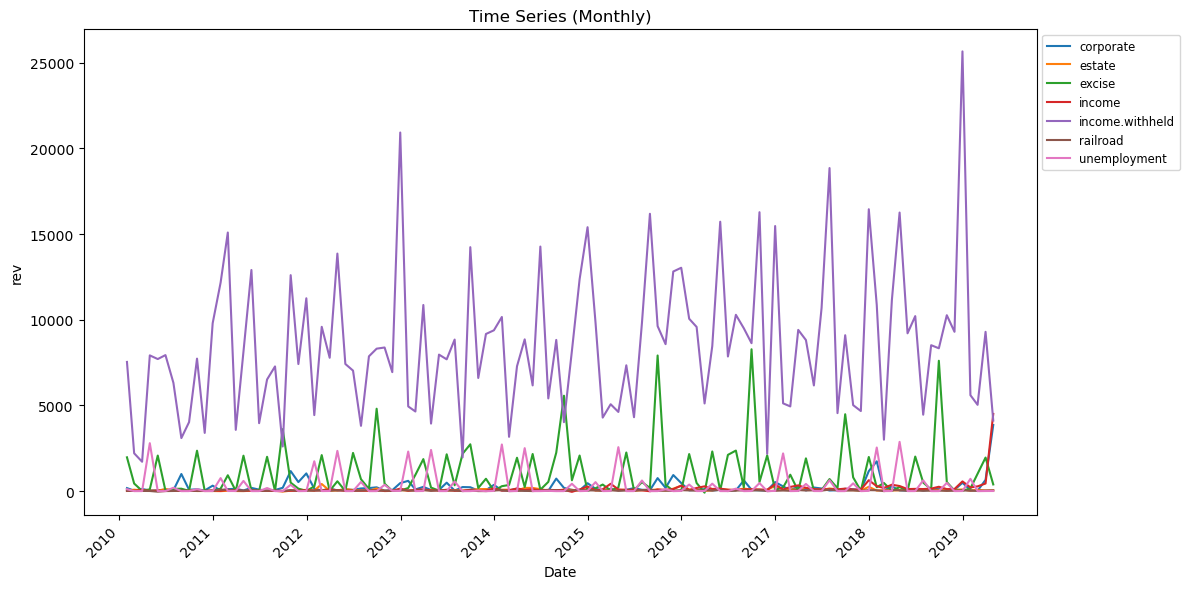

In [9]:
plt.figure(figsize=(12, 6))
for col in pivot_monthly.columns:
    plt.plot(pivot_monthly.index, pivot_monthly[col], label=col)
plt.title('Time Series (Monthly)')
plt.xlabel('Date'); plt.ylabel(value_col)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize='small')
plt.tight_layout()
plt.show()


=== Analysis for series: corporate ===
ADF Statistic: -4.4730, p-value: 0.0002


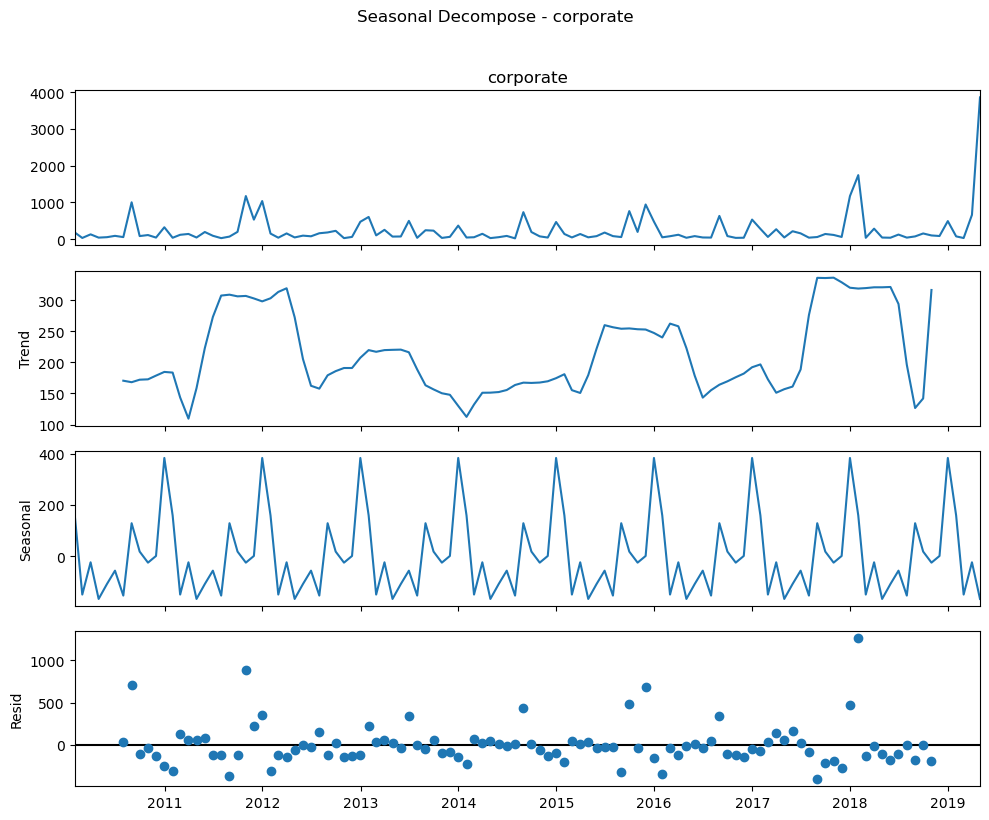

<Figure size 1000x400 with 0 Axes>

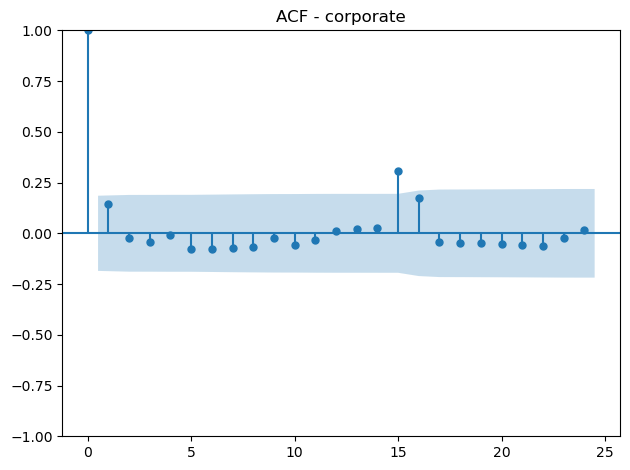

<Figure size 1000x400 with 0 Axes>

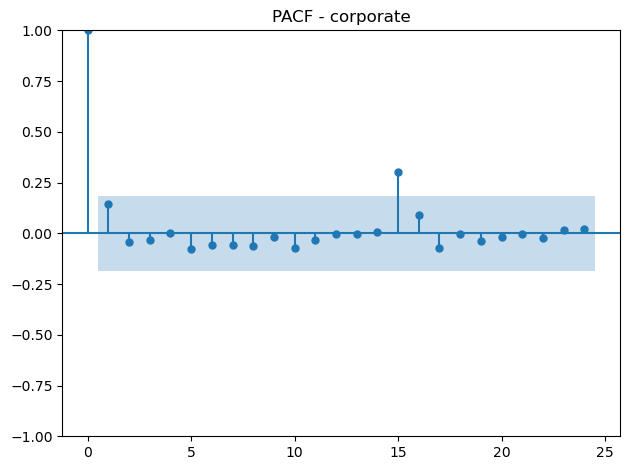

Best ARIMA order: (1, 1, 1), AIC=1675.2
Test MAE: 461.9734, RMSE: 1069.6120


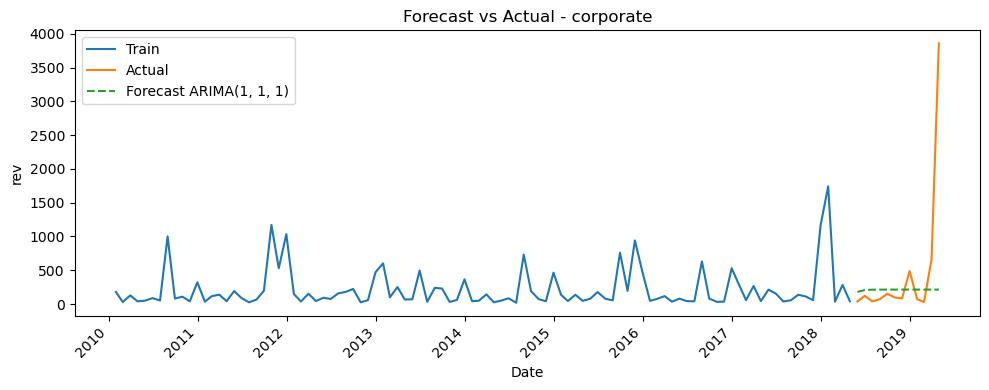

Forecast next periods:


2019-05-31    1668.284966
2019-06-30     875.636887
2019-07-31     588.839669
2019-08-31     485.070233
2019-09-30     447.524206
2019-10-31     433.939242
2019-11-30     429.023908
2019-12-31     427.245434
2020-01-31     426.601944
2020-02-29     426.369115
2020-03-31     426.284872
2020-04-30     426.254392
Freq: ME, Name: predicted_mean, dtype: float64

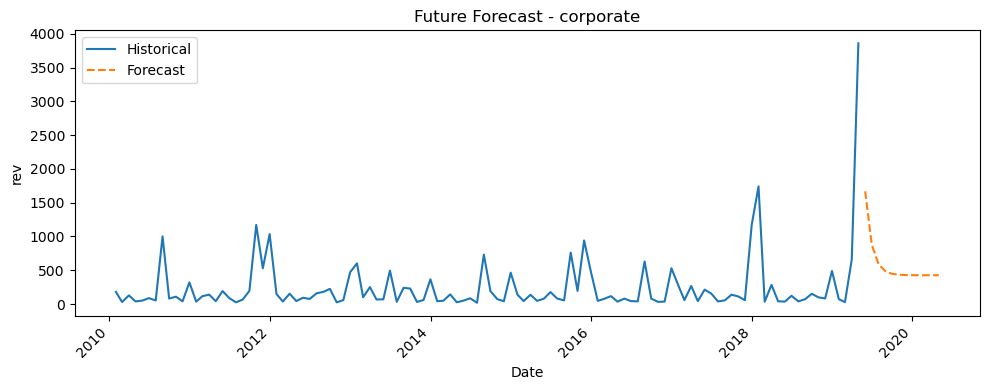

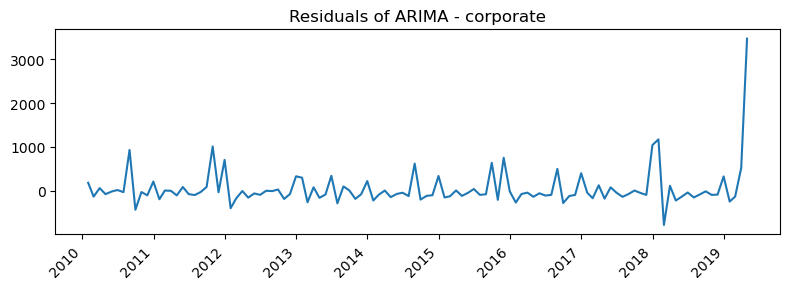

<Figure size 800x300 with 0 Axes>

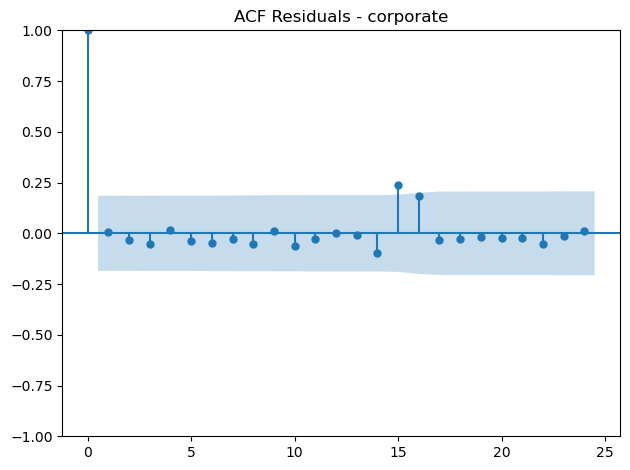

ARCH LM test on ARIMA residuals: LM stat=3.90, p-value=0.9853
Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.

=== Analysis for series: estate ===
ADF Statistic: -9.7457, p-value: 0.0000


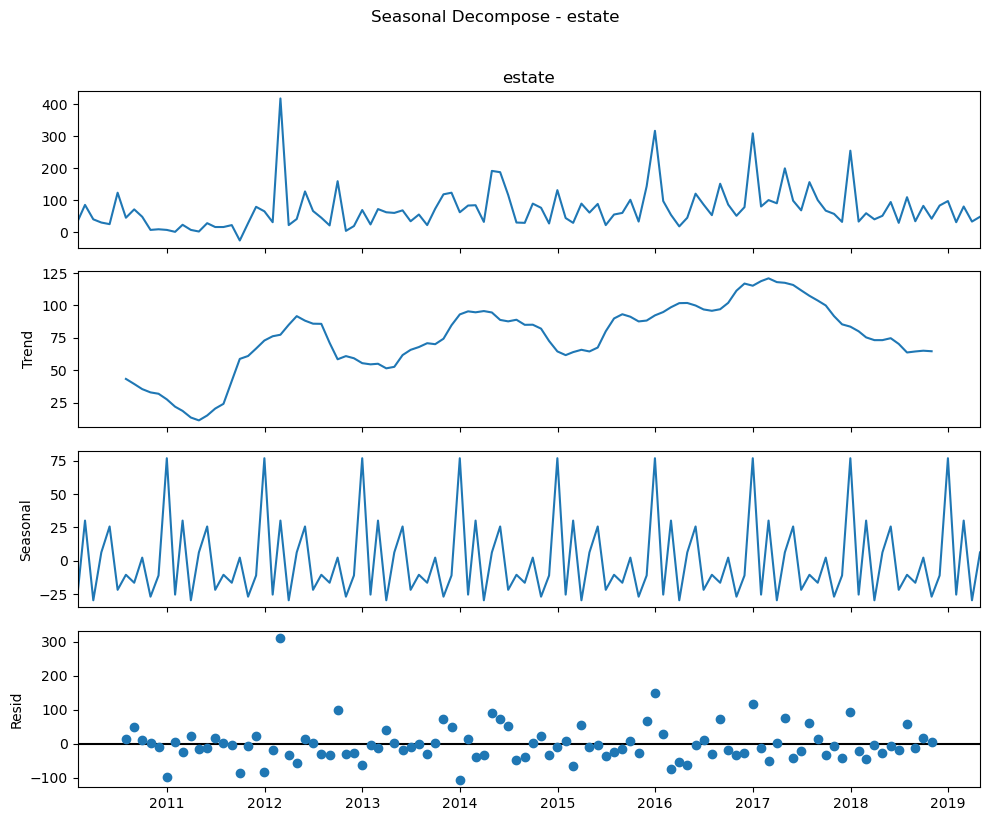

<Figure size 1000x400 with 0 Axes>

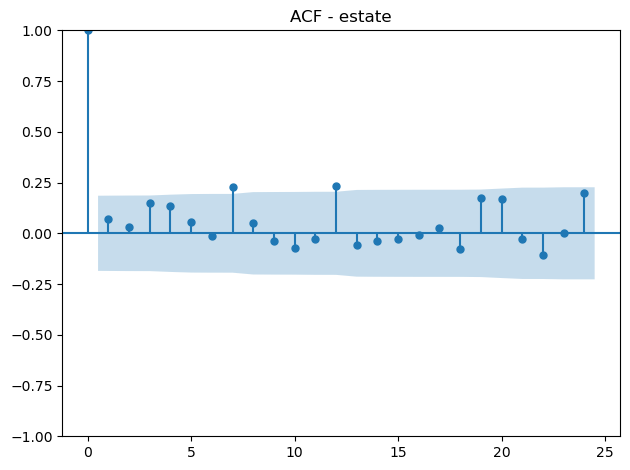

<Figure size 1000x400 with 0 Axes>

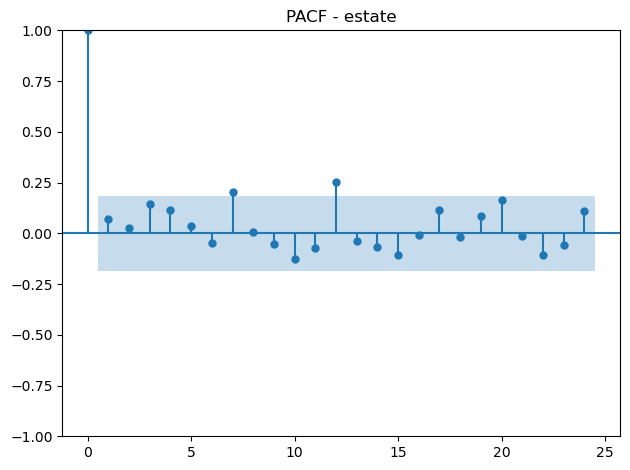

Best ARIMA order: (2, 1, 3), AIC=1246.1
Test MAE: 31.0358, RMSE: 40.1155


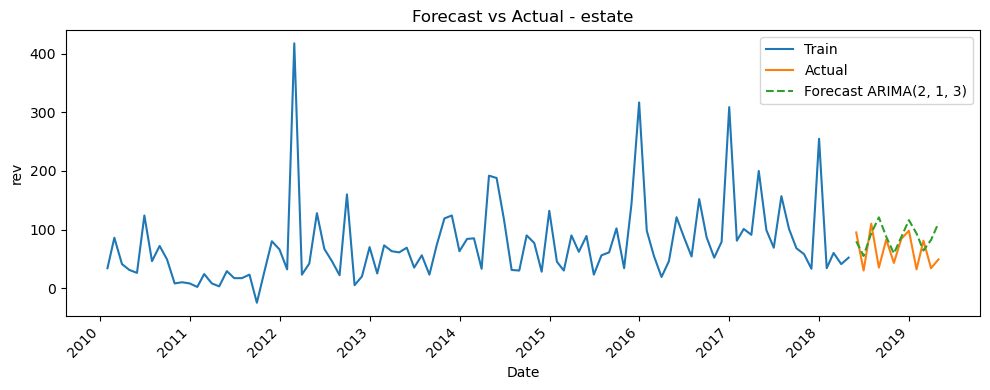

Forecast next periods:


2019-05-31    94.276687
2019-06-30    56.328157
2019-07-31    51.121312
2019-08-31    85.494241
2019-09-30    94.019254
2019-10-31    63.298471
2019-11-30    52.114959
2019-12-31    79.184731
2020-01-31    92.419528
2020-02-29    68.933806
2020-03-31    54.199503
2020-04-30    74.222718
Freq: ME, Name: predicted_mean, dtype: float64

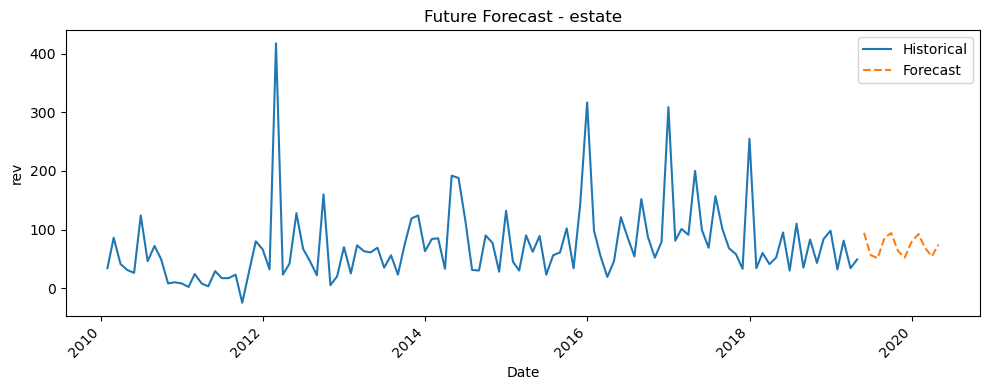

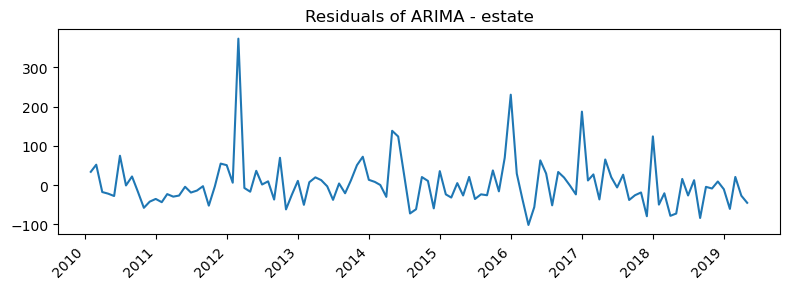

<Figure size 800x300 with 0 Axes>

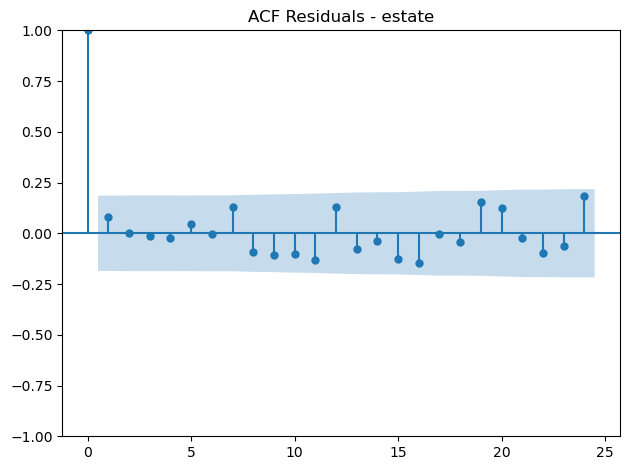

ARCH LM test on ARIMA residuals: LM stat=1.92, p-value=0.9995
Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.

=== Analysis for series: excise ===
ADF Statistic: -2.2236, p-value: 0.1978


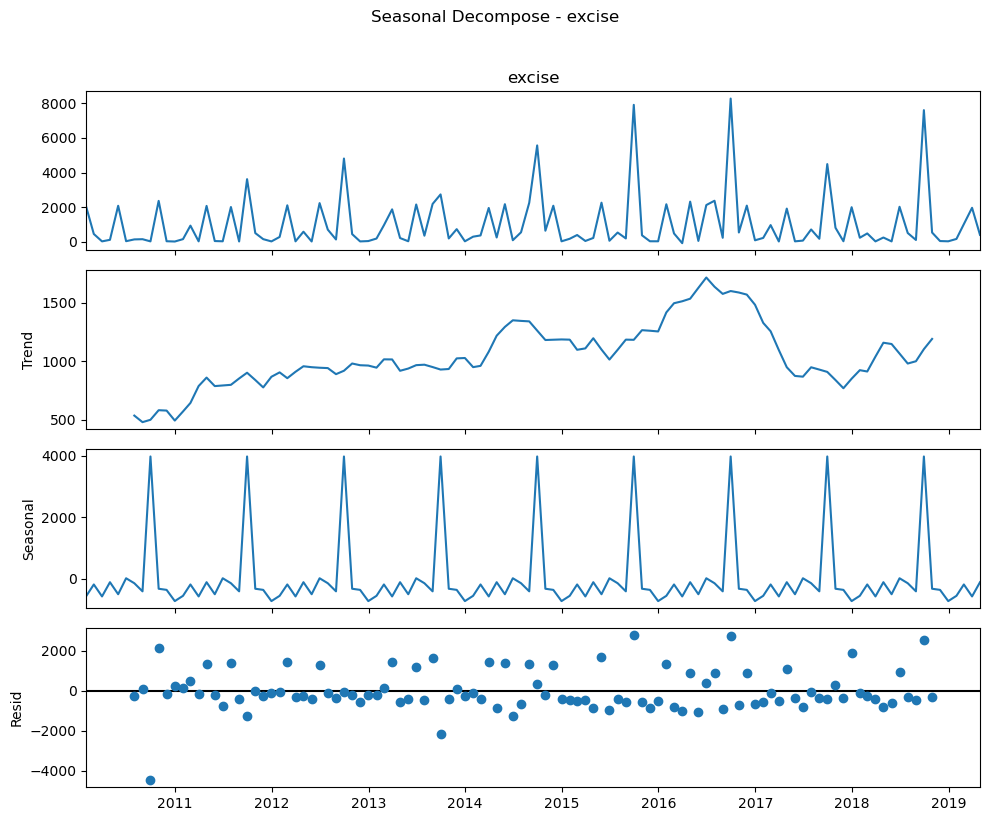

<Figure size 1000x400 with 0 Axes>

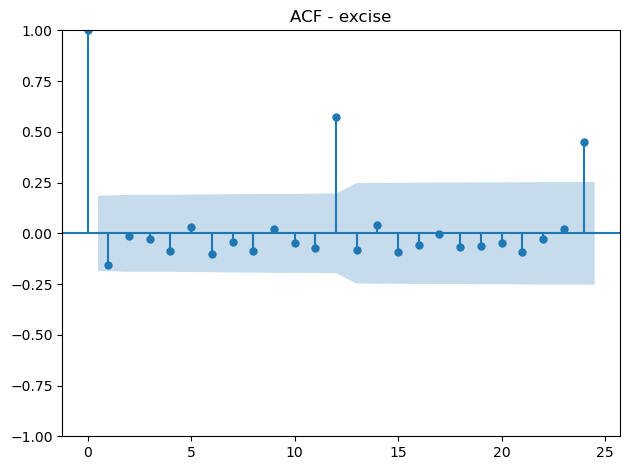

<Figure size 1000x400 with 0 Axes>

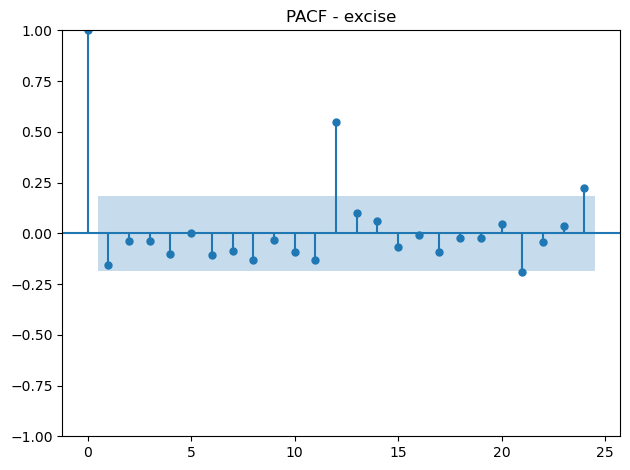

Best ARIMA order: (1, 1, 2), AIC=1957.7
Test MAE: 1249.5496, RMSE: 2062.6876


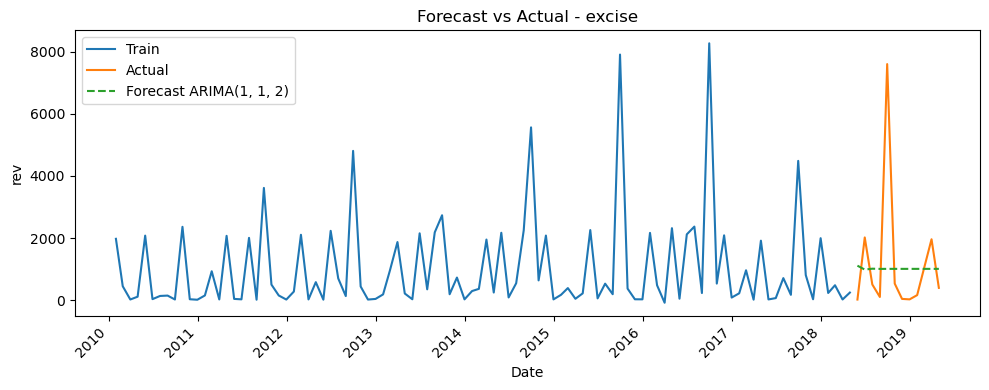

Forecast next periods:


2019-05-31    1066.558117
2019-06-30    1035.390853
2019-07-31    1012.252673
2019-08-31     995.075182
2019-09-30     982.322831
2019-10-31     972.855647
2019-11-30     965.827331
2019-12-31     960.609598
2020-01-31     956.736019
2020-02-29     953.860323
2020-03-31     951.725443
2020-04-30     950.140536
Freq: ME, Name: predicted_mean, dtype: float64

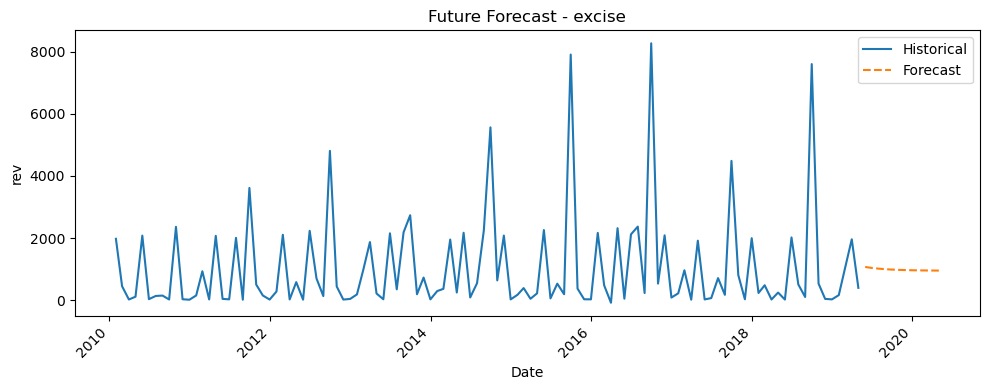

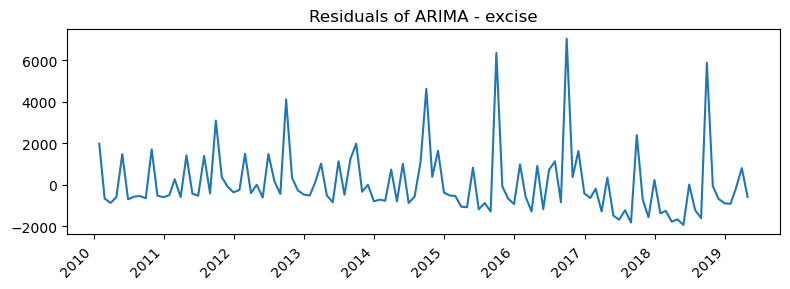

<Figure size 800x300 with 0 Axes>

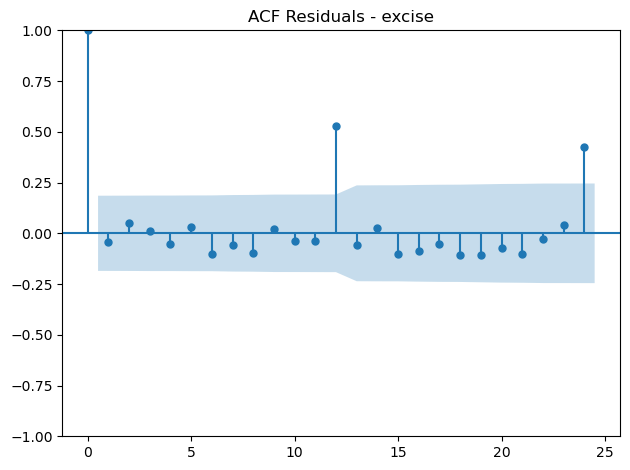

ARCH LM test on ARIMA residuals: LM stat=39.16, p-value=0.0001
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...
GARCH(1,1) fit on ARIMA residuals:
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.009
Vol Model:                            GARCH   Log-Likelihood:               -965.861
Distribution:      Standardized Student's t   AIC:                           1939.72
Method:                  Maximum Likelihood   BIC:                           1950.60
                                              No. Observations:                  112
Date:                      Tue, Jun 24 2025   Df Residuals:                      112
Time:                              10:16:22   Df Model:                            0
                               Volatility Model                   

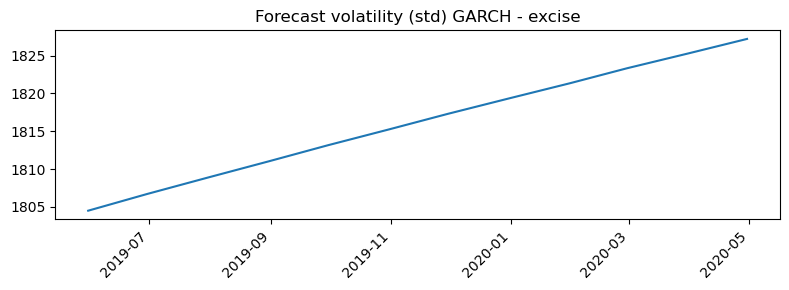


=== Analysis for series: income ===
ADF Statistic: 1.7909, p-value: 0.9983


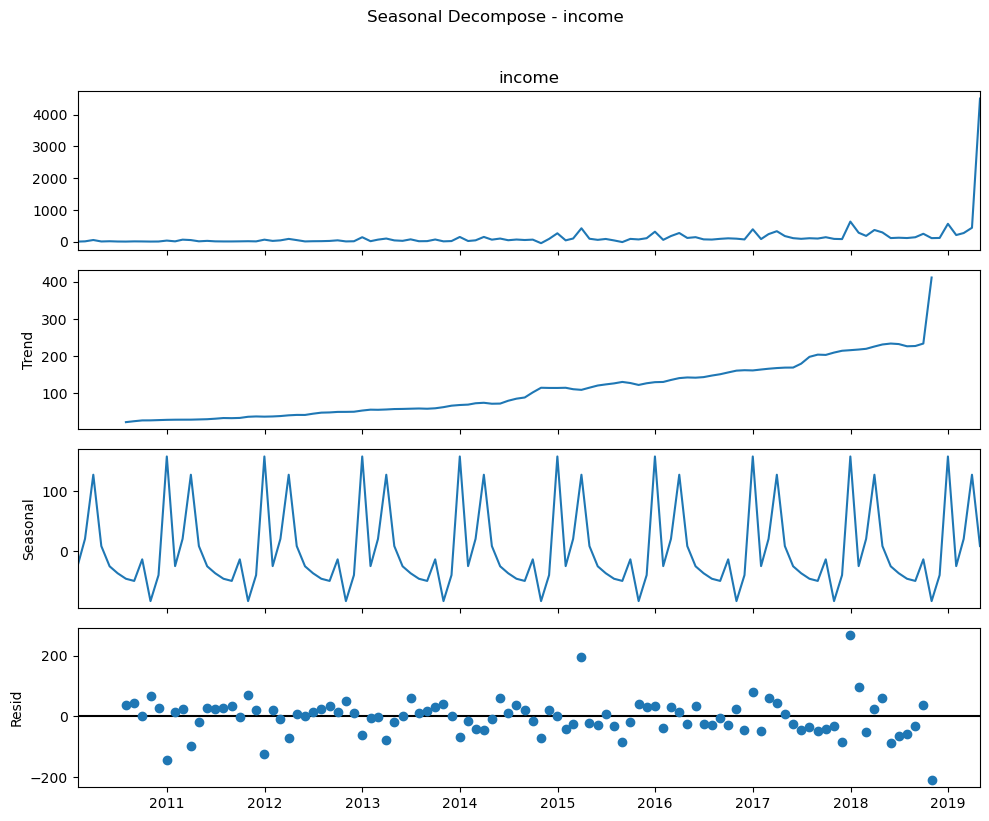

<Figure size 1000x400 with 0 Axes>

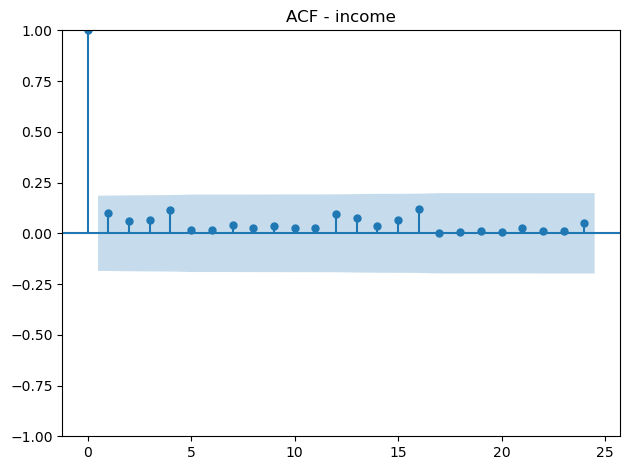

<Figure size 1000x400 with 0 Axes>

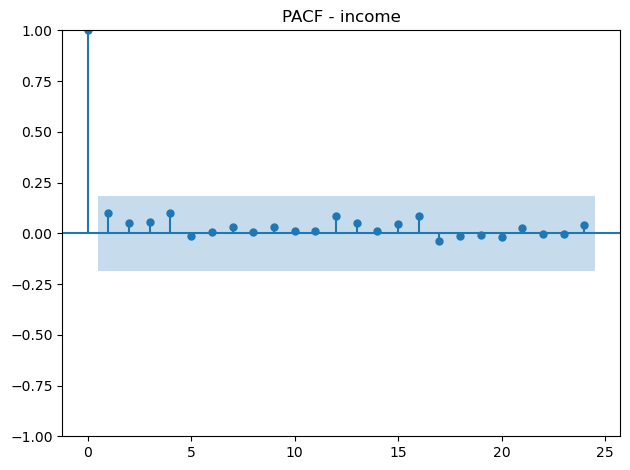

Best ARIMA order: (2, 1, 2), AIC=1649.7
Test MAE: 477.3143, RMSE: 1223.9937


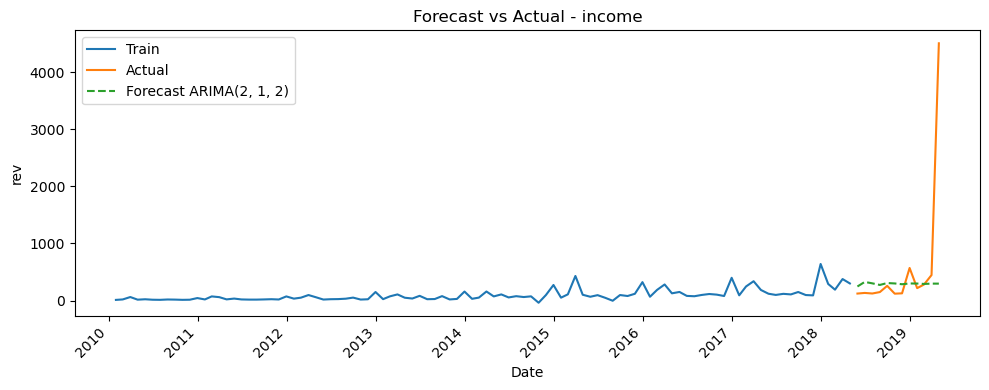

Forecast next periods:


2019-05-31    2024.256376
2019-06-30    2618.133502
2019-07-31    4721.276947
2019-08-31    3733.692319
2019-09-30    2055.049045
2019-10-31    3305.210425
2019-11-30    4545.444120
2019-12-31    3153.644255
2020-01-31    2338.255292
2020-02-29    3765.846132
2020-03-31    4191.411965
2020-04-30    2815.678796
Freq: ME, Name: predicted_mean, dtype: float64

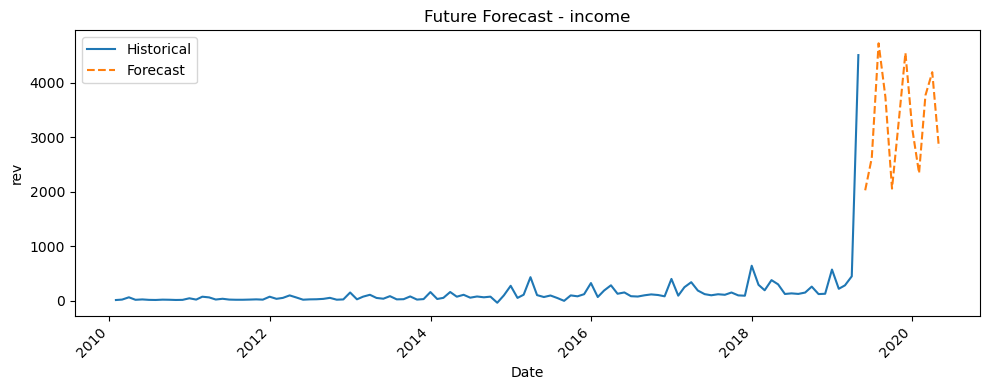

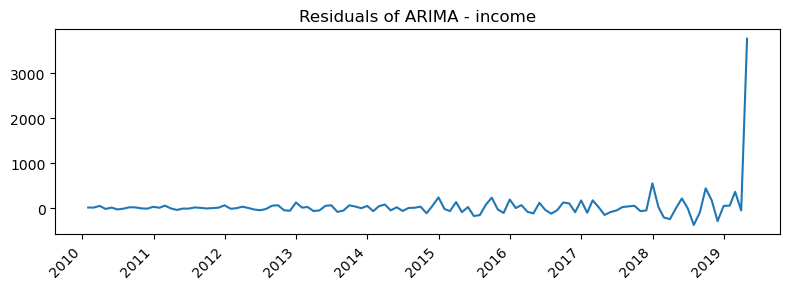

<Figure size 800x300 with 0 Axes>

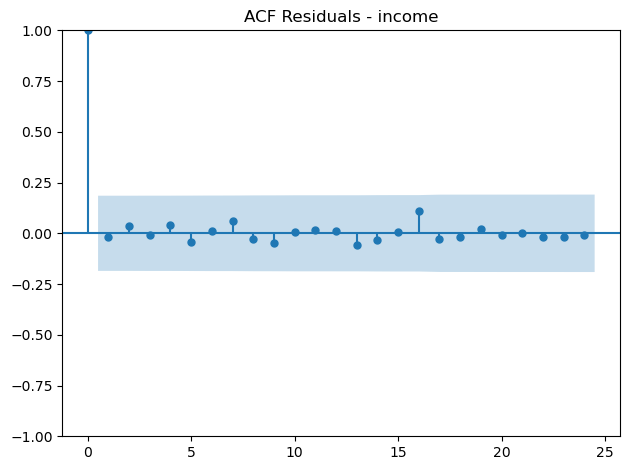

ARCH LM test on ARIMA residuals: LM stat=33.75, p-value=0.0007
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...
GARCH(1,1) fit on ARIMA residuals:
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.009
Vol Model:                            GARCH   Log-Likelihood:               -687.840
Distribution:      Standardized Student's t   AIC:                           1383.68
Method:                  Maximum Likelihood   BIC:                           1394.55
                                              No. Observations:                  112
Date:                      Tue, Jun 24 2025   Df Residuals:                      112
Time:                              10:16:39   Df Model:                            0
                               Volatility Model                   

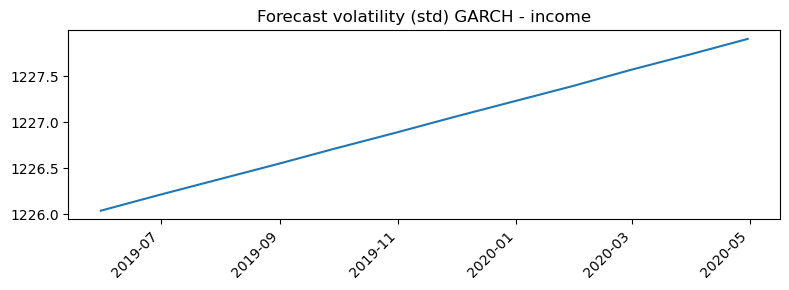


=== Analysis for series: income.withheld ===
ADF Statistic: -11.4117, p-value: 0.0000


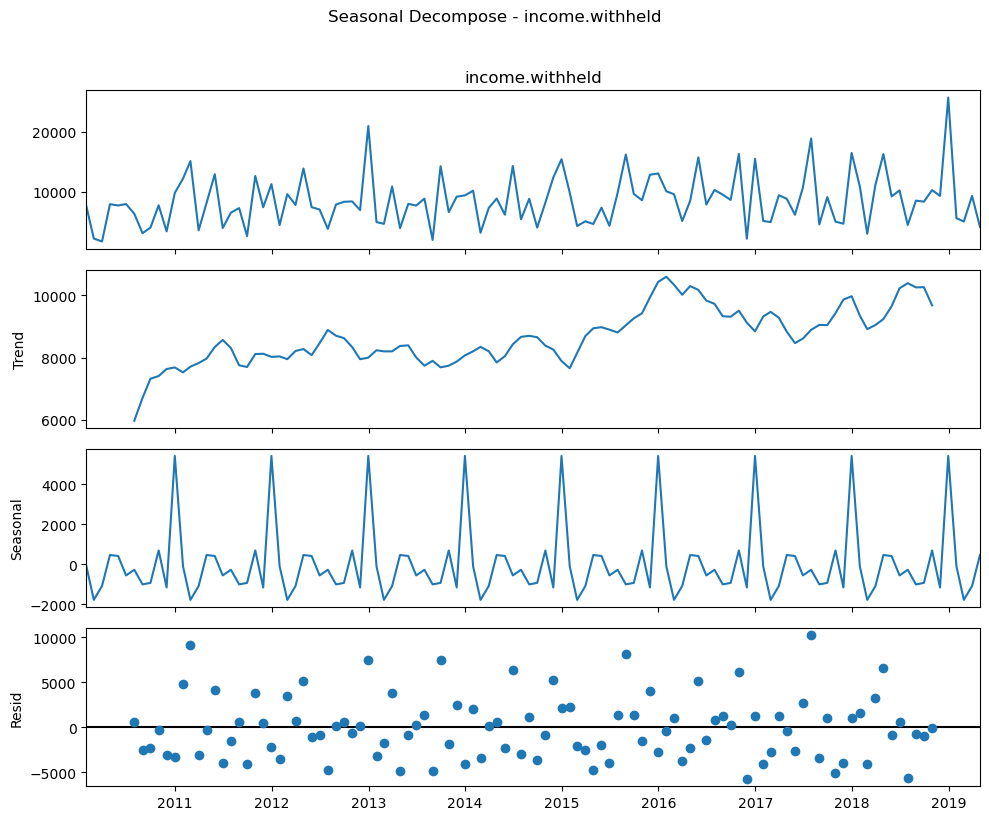

<Figure size 1000x400 with 0 Axes>

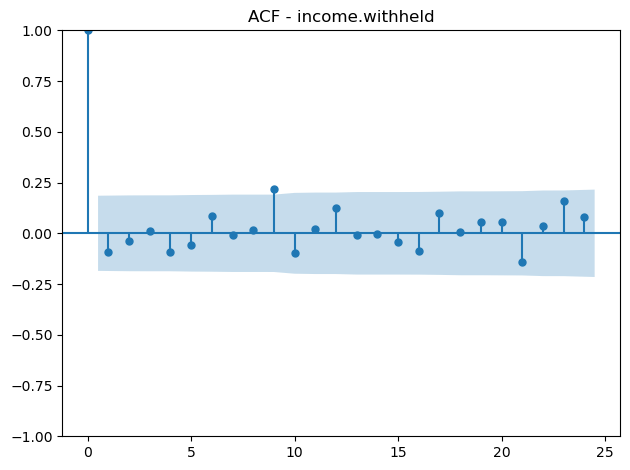

<Figure size 1000x400 with 0 Axes>

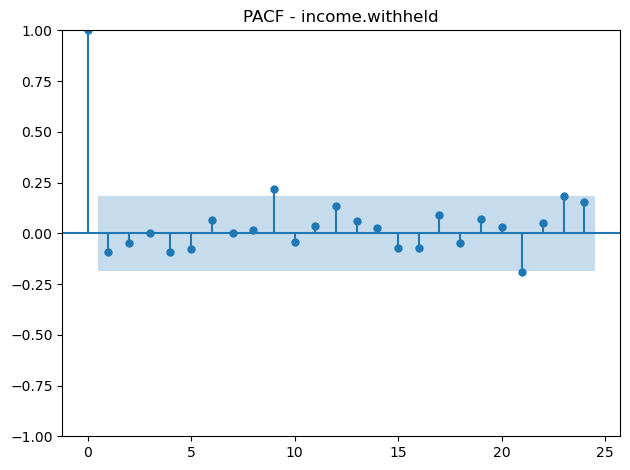

Best ARIMA order: (1, 1, 2), AIC=2175.6
Test MAE: 3300.8113, RMSE: 5416.4448


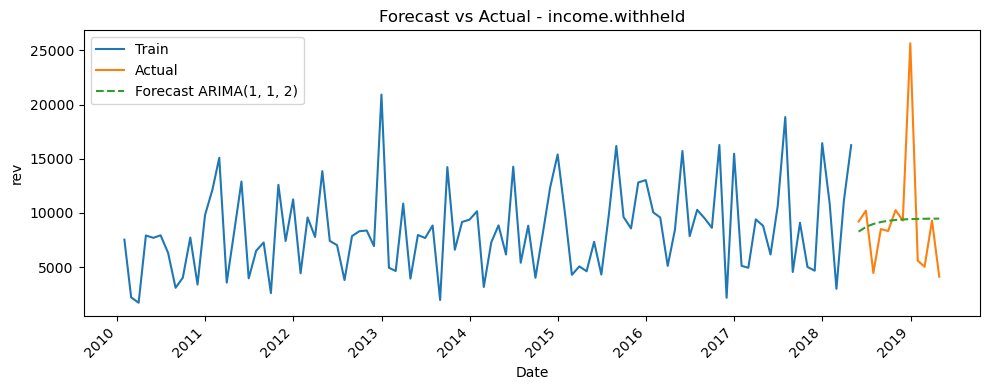

Forecast next periods:


2019-05-31    10534.126392
2019-06-30    10182.325746
2019-07-31     9957.864706
2019-08-31     9814.650761
2019-09-30     9723.275287
2019-10-31     9664.974558
2019-11-30     9627.776666
2019-12-31     9604.043119
2020-01-31     9588.900290
2020-02-29     9579.238640
2020-03-31     9573.074171
2020-04-30     9569.141025
Freq: ME, Name: predicted_mean, dtype: float64

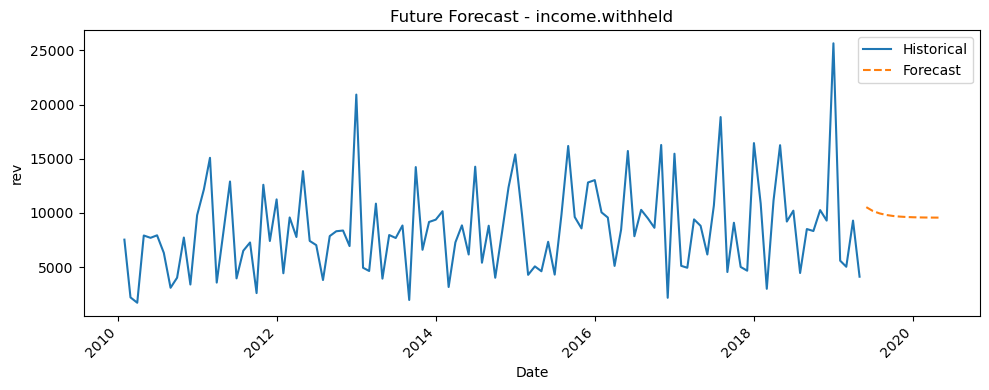

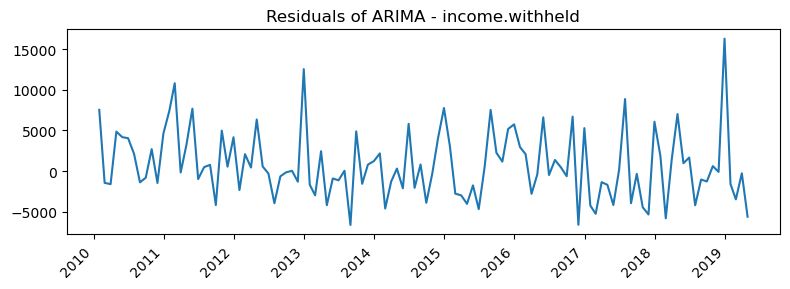

<Figure size 800x300 with 0 Axes>

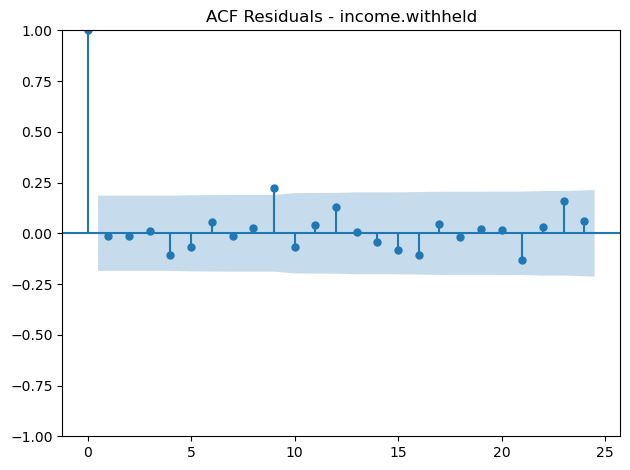

ARCH LM test on ARIMA residuals: LM stat=10.98, p-value=0.5309
Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.

=== Analysis for series: railroad ===
ADF Statistic: -9.9394, p-value: 0.0000


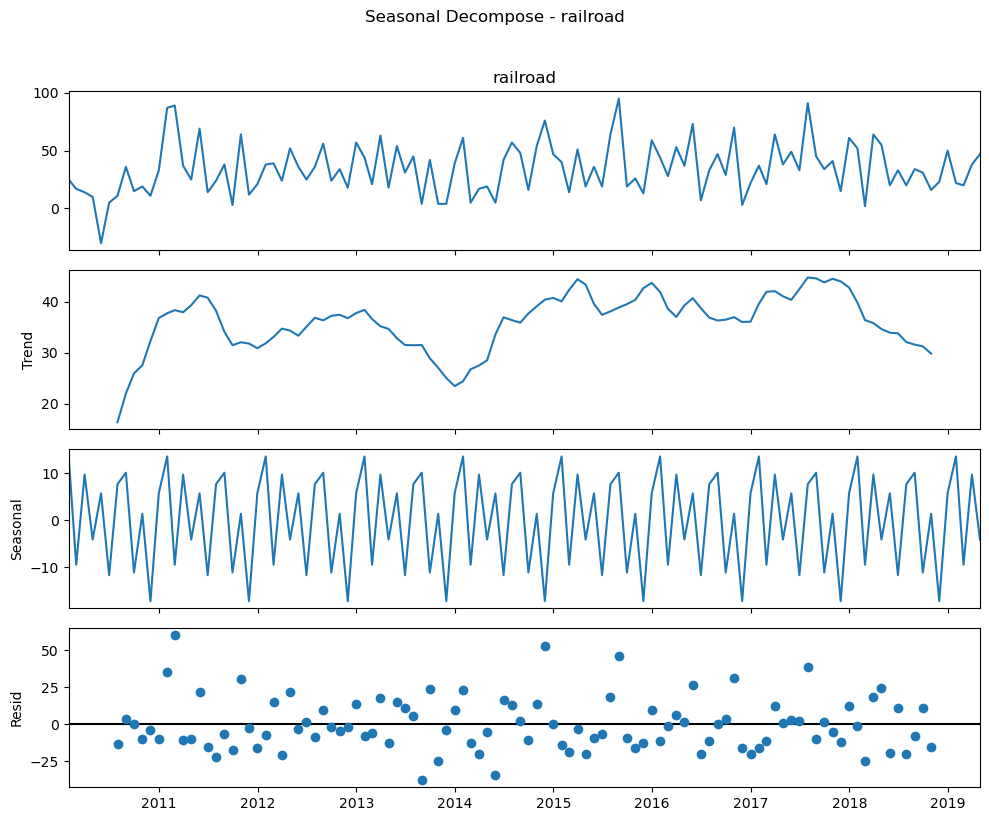

<Figure size 1000x400 with 0 Axes>

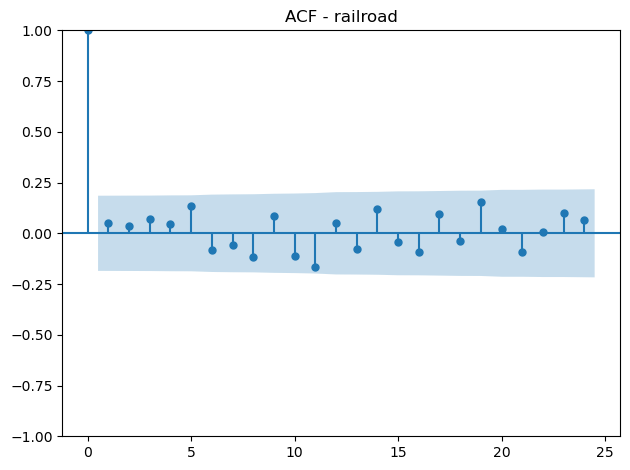

<Figure size 1000x400 with 0 Axes>

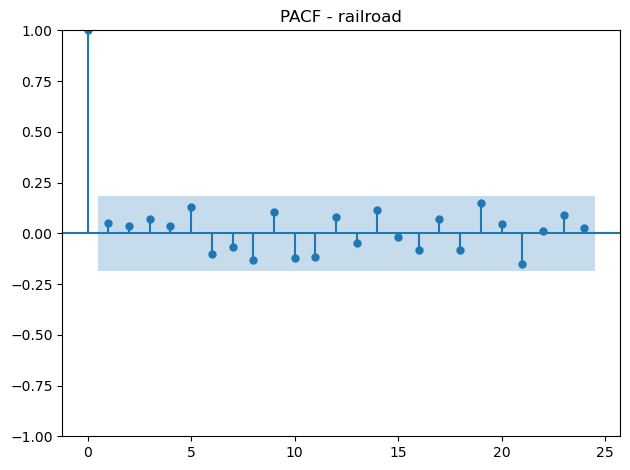

Best ARIMA order: (0, 1, 1), AIC=1008.9
Test MAE: 13.9538, RMSE: 15.6869


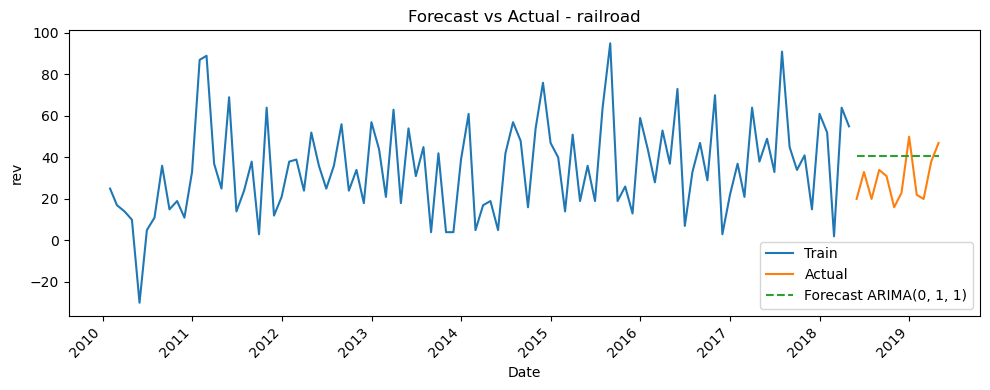

Forecast next periods:


2019-05-31    36.005905
2019-06-30    36.005905
2019-07-31    36.005905
2019-08-31    36.005905
2019-09-30    36.005905
2019-10-31    36.005905
2019-11-30    36.005905
2019-12-31    36.005905
2020-01-31    36.005905
2020-02-29    36.005905
2020-03-31    36.005905
2020-04-30    36.005905
Freq: ME, Name: predicted_mean, dtype: float64

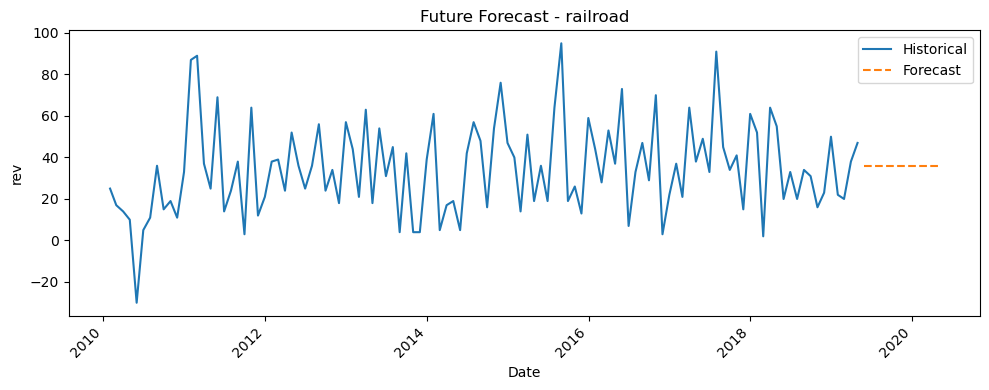

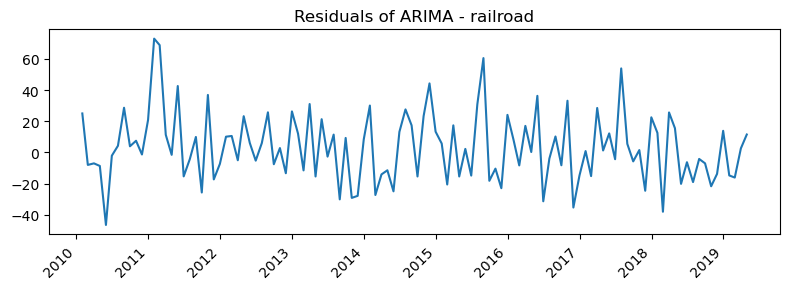

<Figure size 800x300 with 0 Axes>

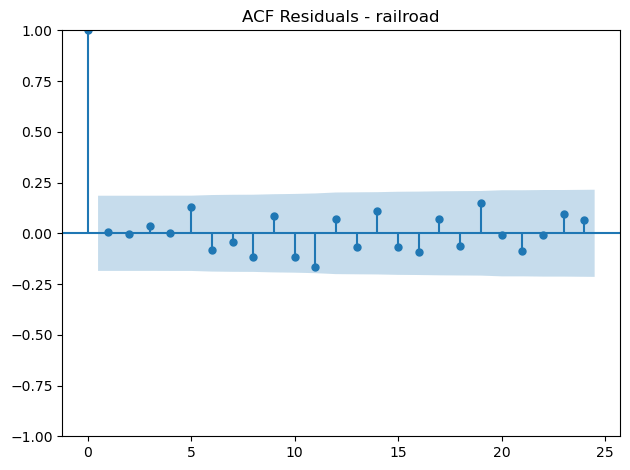

ARCH LM test on ARIMA residuals: LM stat=21.14, p-value=0.0483
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...
GARCH(1,1) fit on ARIMA residuals:
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.009
Vol Model:                            GARCH   Log-Likelihood:               -504.466
Distribution:      Standardized Student's t   AIC:                           1016.93
Method:                  Maximum Likelihood   BIC:                           1027.81
                                              No. Observations:                  112
Date:                      Tue, Jun 24 2025   Df Residuals:                      112
Time:                              10:17:02   Df Model:                            0
                              Volatility Model                    

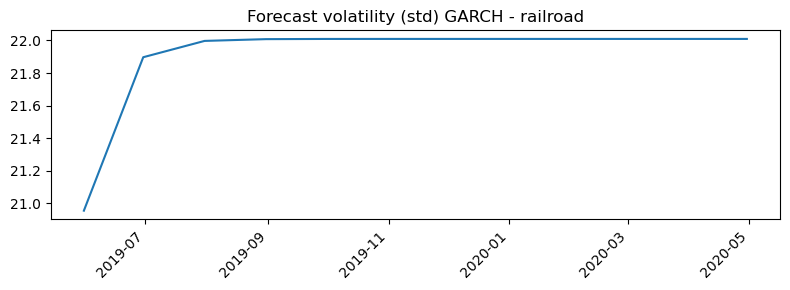


=== Analysis for series: unemployment ===
ADF Statistic: -2.2222, p-value: 0.1983


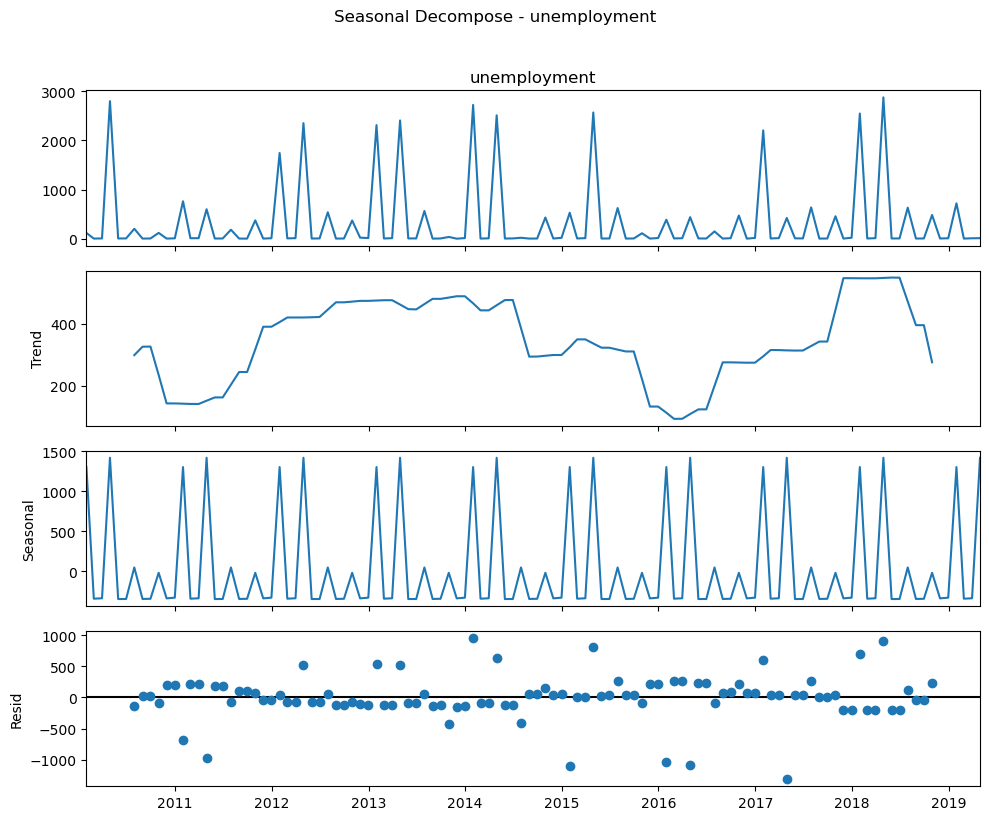

<Figure size 1000x400 with 0 Axes>

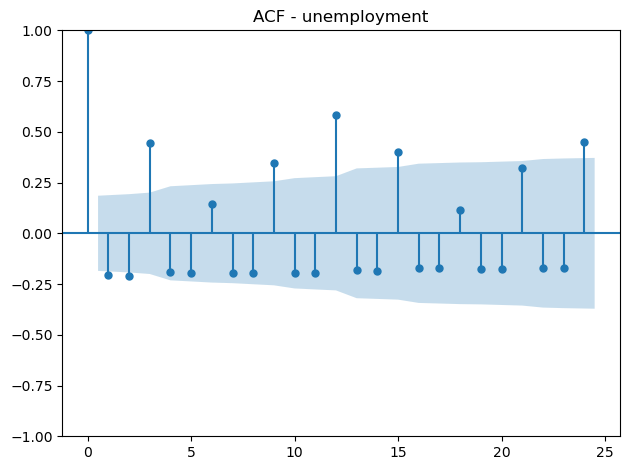

<Figure size 1000x400 with 0 Axes>

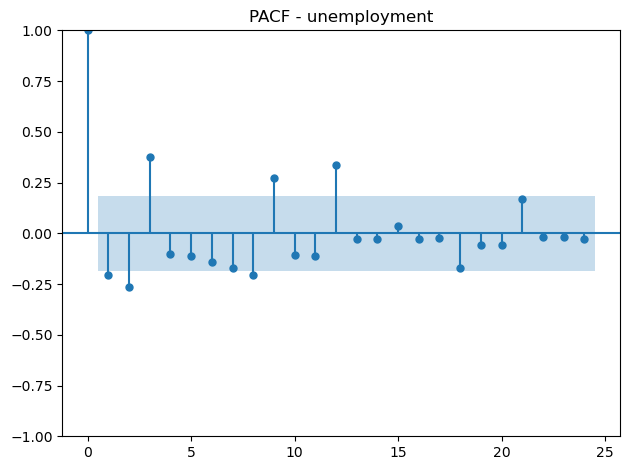

Best ARIMA order: (2, 1, 3), AIC=1752.9
Test MAE: 195.8621, RMSE: 361.4824


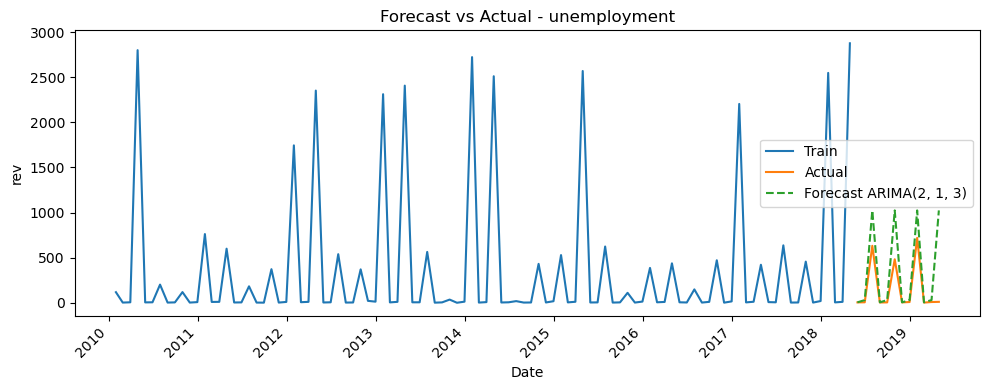

Forecast next periods:


2019-05-31     10.727266
2019-06-30     22.937933
2019-07-31    962.220990
2019-08-31     10.375456
2019-09-30     23.305031
2019-10-31    962.205560
2019-11-30     10.023798
2019-12-31     23.672252
2020-01-31    962.189856
2020-02-29      9.672290
2020-03-31     24.039594
2020-04-30    962.173880
Freq: ME, Name: predicted_mean, dtype: float64

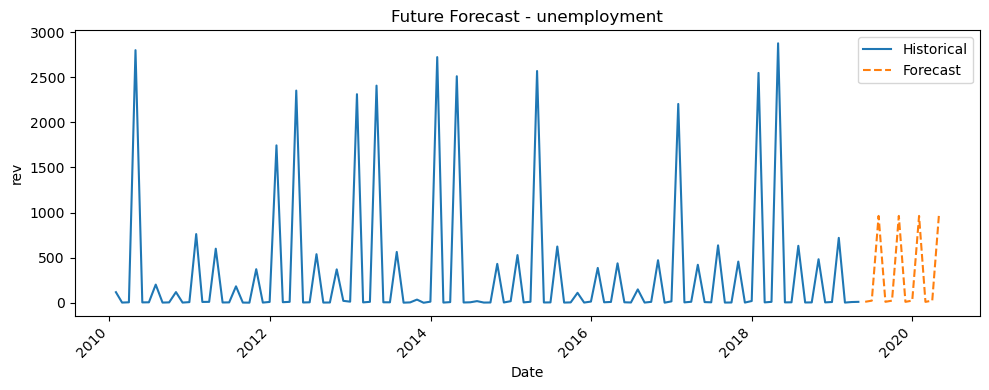

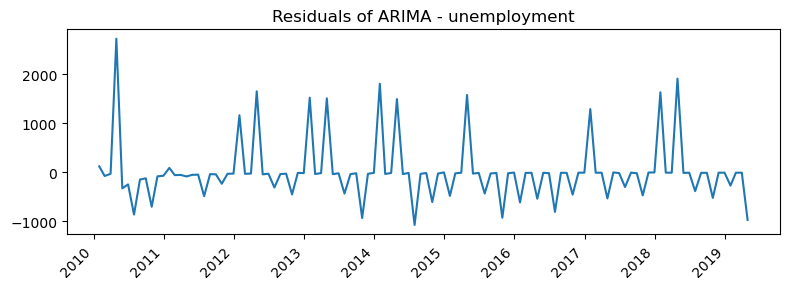

<Figure size 800x300 with 0 Axes>

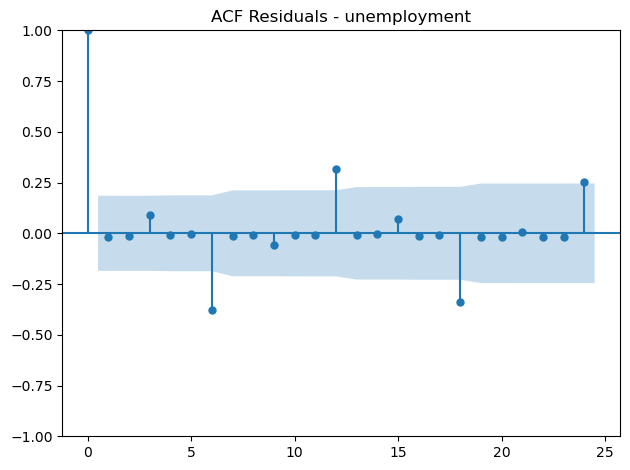

ARCH LM test on ARIMA residuals: LM stat=34.21, p-value=0.0006
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...
GARCH(1,1) fit on ARIMA residuals:
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.009
Vol Model:                            GARCH   Log-Likelihood:               -831.277
Distribution:      Standardized Student's t   AIC:                           1670.55
Method:                  Maximum Likelihood   BIC:                           1681.43
                                              No. Observations:                  112
Date:                      Tue, Jun 24 2025   Df Residuals:                      112
Time:                              10:17:12   Df Model:                            0
                               Volatility Model                   

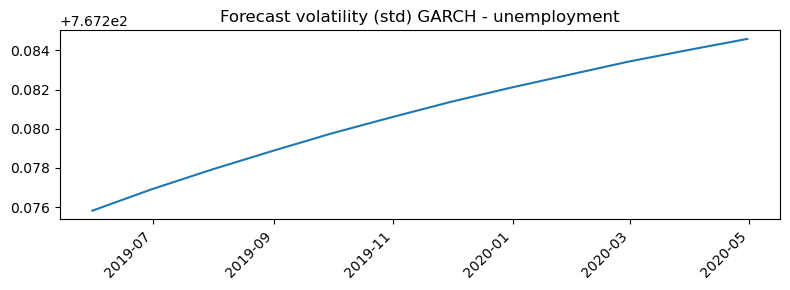

In [10]:
# 8. Analysis function including ARCH/GARCH test
def analyze_series_with_arch(ts, name, freq='M', max_p=3, max_d=1, max_q=3, test_periods=12):
    """
    Phân tích chuỗi ts (pd.Series indexed by datetime):
    - ADF test
    - Seasonal decomposition (nếu đủ dữ liệu)
    - ACF/PACF plot
    - Grid search ARIMA (p,d,q) tối ưu AIC trên toàn chuỗi
    - Train-test đánh giá MAE/RMSE
    - Fit final ARIMA trên toàn chuỗi, forecast tương lai
    - Kiểm định ARCH trên residual của ARIMA
    - Nếu có ARCH effect, thử fit GARCH(1,1) trên residuals
    """
    print(f"\n=== Analysis for series: {name} ===")
    ts_clean = ts.dropna()
    n = len(ts_clean)
    if n == 0:
        print("Chuỗi rỗng, bỏ qua.")
        return
    if n < (test_periods + max_p + max_q):
        print("Chuỗi có thể ngắn, train-test ARIMA có thể không đáng tin.")
    # ADF test
    try:
        result = adfuller(ts_clean)
        print(f"ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    except Exception as e:
        print("ADF test error:", e)
    # Seasonal decomposition nếu đủ >=24 obs
    if n >= 24:
        try:
            decomp = seasonal_decompose(ts_clean, model='additive', period=12)
            fig = decomp.plot()
            fig.set_size_inches(10, 8)
            fig.suptitle(f'Seasonal Decompose - {name}', y=1.02)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("Decomposition error:", e)
    # ACF/PACF
    try:
        plt.figure(figsize=(10,4))
        plot_acf(ts_clean, lags=24); plt.title(f'ACF - {name}'); plt.tight_layout(); plt.show()
        plt.figure(figsize=(10,4))
        plot_pacf(ts_clean, lags=24, method='ywm'); plt.title(f'PACF - {name}'); plt.tight_layout(); plt.show()
    except Exception as e:
        print("ACF/PACF error:", e)
    # Grid search ARIMA full series
    best_aic = np.inf; best_order = None
    for p in range(max_p+1):
        for d in range(max_d+1):
            for q in range(max_q+1):
                try:
                    res = ARIMA(ts_clean, order=(p,d,q)).fit()
                    if res.aic < best_aic:
                        best_aic = res.aic; best_order = (p,d,q)
                except:
                    continue
    if best_order is None:
        print("Không tìm được ARIMA phù hợp.")
        return
    print(f"Best ARIMA order: {best_order}, AIC={best_aic:.1f}")
    # Train-test ARIMA
    if n > test_periods:
        train = ts_clean.iloc[:-test_periods]; test = ts_clean.iloc[-test_periods:]
        try:
            res_train = ARIMA(train, order=best_order).fit()
            forecast = res_train.forecast(steps=test_periods); forecast.index = test.index
            mae = mean_absolute_error(test, forecast); rmse = np.sqrt(mean_squared_error(test, forecast))
            print(f"Test MAE: {mae:.4f}, RMSE: {rmse:.4f}")
            plt.figure(figsize=(10,4))
            plt.plot(train.index, train, label='Train')
            plt.plot(test.index, test, label='Actual')
            plt.plot(forecast.index, forecast, label=f'Forecast ARIMA{best_order}', linestyle='--')
            plt.title(f'Forecast vs Actual - {name}'); plt.xlabel('Date'); plt.ylabel(value_col)
            plt.legend(); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
        except Exception as e:
            print("Train-test ARIMA error:", e)
    # Fit full ARIMA and forecast future
    try:
        res_full = ARIMA(ts_clean, order=best_order).fit()
        horizon = 12
        future = res_full.forecast(steps=horizon)
        last_date = ts_clean.index[-1]
        if freq == 'M':
            future_idx = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=horizon, freq='M')
        elif freq == 'D':
            future_idx = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=horizon, freq='D')
        else:
            future_idx = None
        if future_idx is not None:
            future.index = future_idx
        print("Forecast next periods:"); display(future)
        plt.figure(figsize=(10,4))
        plt.plot(ts_clean, label='Historical')
        plt.plot(future.index, future, label='Forecast', linestyle='--')
        plt.title(f'Future Forecast - {name}'); plt.xlabel('Date'); plt.ylabel(value_col)
        plt.legend(); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Final ARIMA error:", e)
    # Residuals of ARIMA
    try:
        resid = res_full.resid
        plt.figure(figsize=(8,3))
        plt.plot(resid.index, resid.values)
        plt.title(f'Residuals of ARIMA - {name}'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
        plt.figure(figsize=(8,3))
        plot_acf(resid.dropna(), lags=24)
        plt.title(f'ACF Residuals - {name}'); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Residual plot error:", e)
    # ARCH test on residuals
    lm_pvalue = None
    try:
        lm_stat, lm_pvalue, _, _ = het_arch(resid.dropna(), nlags=12)
        print(f"ARCH LM test on ARIMA residuals: LM stat={lm_stat:.2f}, p-value={lm_pvalue:.4f}")
    except Exception as e:
        print("ARCH test error:", e)
    # If ARCH effect present, try GARCH
    if lm_pvalue is not None and lm_pvalue < 0.05:
        print("Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...")
        try:
            from arch import arch_model
        except ImportError:
            print("Cần cài thư viện 'arch' để fit GARCH: pip install arch")
            return
        resid_centered = resid.dropna() - resid.dropna().mean()
        try:
            am = arch_model(resid_centered, mean='Zero', vol='GARCH', p=1, o=0, q=1, dist='t')
            res_garch = am.fit(update_freq=5, disp='off')
            print("GARCH(1,1) fit on ARIMA residuals:")
            print(res_garch.summary())
            params = res_garch.params
            if 'alpha[1]' in params and 'beta[1]' in params:
                print("Alpha+Beta =", params['alpha[1]'] + params['beta[1]'])
            std_resid = res_garch.std_resid
            lb = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
            print("Ljung-Box on squared std residuals:", lb)
            horizon = 12
            fc = res_garch.forecast(horizon=horizon, reindex=False)
            var_fc = fc.variance.iloc[-1]
            last_idx = resid_centered.index[-1]
            if freq == 'M':
                future_idx = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=horizon, freq='M')
            elif freq == 'D':
                future_idx = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=horizon, freq='D')
            else:
                future_idx = None
            if future_idx is not None:
                var_fc.index = future_idx
            vol_fc = np.sqrt(var_fc)
            plt.figure(figsize=(8,3))
            plt.plot(vol_fc.index, vol_fc.values)
            plt.title(f'Forecast volatility (std) GARCH - {name}'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
        except Exception as e:
            print("Error fitting GARCH:", e)
    else:
        print("Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.")

# 9. Apply for each series
for col in pivot_monthly.columns:
    analyze_series_with_arch(pivot_monthly[col], col)

Columns: ['ds', 'mtd', 'rev', 'type', 'ytd']<br>
ds      object<br>
mtd      int64<br>
rev      int64<br>
type    object<br>
ytd      int64<br>
dtype: object<br>
Chọn date_col = ds<br>
Chọn value_col: rev, category_col: type <br>

=== Analysis for series: corporate ===<br>
ADF Statistic: -4.4730, p-value: 0.0002<br>
Best ARIMA order: (1, 1, 1), AIC=1675.2<br>
Test MAE: 461.9734, RMSE: 1069.6120<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=3.90, p-value=0.9853<br>
Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.<br>
<br>
=== Analysis for series: estate ===<br>
ADF Statistic: -9.7457, p-value: 0.0000<br>
Best ARIMA order: (2, 1, 3), AIC=1246.5<br>
Test MAE: 32.2541, RMSE: 41.7137<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=1.98, p-value=0.9994<br>
Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.<br>
<br>
=== Analysis for series: excise ===<br>
ADF Statistic: -2.2236, p-value: 0.1978<br>
Best ARIMA order: (1, 1, 2), AIC=1957.7<br>
Test MAE: 1249.5497, RMSE: 2062.6877<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=39.16, p-value=0.0001<br>
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...<br>
Cần cài thư viện 'arch' để fit GARCH: pip install arch<br>
<br>
=== Analysis for series: income ===<br>
ADF Statistic: 1.7909, p-value: 0.9983<br>
Best ARIMA order: (2, 1, 2), AIC=1649.7<br>
Test MAE: 477.3143, RMSE: 1223.9937<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=33.71, p-value=0.0007<br>
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...<br>
Cần cài thư viện 'arch' để fit GARCH: pip install arch<br>
<br>
=== Analysis for series: income.withheld ===<br>
ADF Statistic: -11.4117, p-value: 0.0000<br>
Best ARIMA order: (1, 1, 2), AIC=2175.6<br>
Test MAE: 3300.8156, RMSE: 5416.4447<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=10.98, p-value=0.5309<br>
Không phát hiện ARCH effect (p >= 0.05), không fit GARCH.<br>
<br>
=== Analysis for series: railroad ===<br>
ADF Statistic: -9.9394, p-value: 0.0000<br>
Best ARIMA order: (0, 1, 1), AIC=1008.9<br>
Test MAE: 13.9538, RMSE: 15.6869<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=21.14, p-value=0.0483<br>
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...<br>
Cần cài thư viện 'arch' để fit GARCH: pip install arch<br>
<br>
=== Analysis for series: unemployment ===<br>
ADF Statistic: -2.2222, p-value: 0.1983<br>
Best ARIMA order: (2, 1, 3), AIC=1752.9<br>
Test MAE: 195.8630, RMSE: 361.2738<br>
Forecast next periods:<br>
ARCH LM test on ARIMA residuals: LM stat=34.33, p-value=0.0006<br>
Phát hiện ARCH effect (p < 0.05). Thử fit GARCH(1,1) trên residuals...<br>
Cần cài thư viện 'arch' để fit GARCH: pip install arch<br>

# EDA

In [11]:
print(df.head())

          ds     mtd   rev             type      ytd
0 2014-07-17     720    23           estate    14988
1 2014-07-17  100167  2450  income.withheld  1677618
2 2014-07-17     727    53           income    62440
3 2014-07-17     289     1         railroad     4620
4 2014-07-17    3678    24           excise    61590


In [12]:
# null
print("\n>> Số lượng giá trị thiếu:")
print(df.isnull().sum())

print("\n>> Kiểu dữ liệu:")
print(df.dtypes)


>> Số lượng giá trị thiếu:
ds      0
mtd     0
rev     0
type    0
ytd     0
dtype: int64

>> Kiểu dữ liệu:
ds      datetime64[ns]
mtd              int64
rev              int64
type            object
ytd              int64
dtype: object


In [13]:
# Đổi tên cột cho thống nhất
df.columns = [col.lower().strip() for col in df.columns]
date_col = 'ds' if 'ds' in df.columns else df.columns[0]
value_col = 'rev' if 'rev' in df.columns else df.columns[1]
type_col = 'type' if 'type' in df.columns else df.columns[2]

In [14]:
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])
df = df.sort_values(by=date_col)

In [15]:
print("\n>> Mô tả thống kê:")
print(df.describe())


>> Mô tả thống kê:
                                  ds            mtd           rev  \
count                          18248   18248.000000  18248.000000   
mean   2014-08-24 09:08:36.089434368   15031.176732   1286.974025   
min              2010-01-04 00:00:00     -42.000000  -1585.000000   
25%              2012-04-23 00:00:00      89.000000      7.000000   
50%              2014-09-04 00:00:00     446.500000     40.000000   
75%              2016-12-23 00:00:00    3689.250000    166.000000   
max              2019-04-11 00:00:00  237654.000000  59518.000000   
std                              NaN   37302.756726   3989.461047   

                ytd  
count  1.824800e+04  
mean   1.608718e+05  
min   -4.200000e+01  
25%    2.085750e+03  
50%    8.739500e+03  
75%    7.089800e+04  
max    2.413019e+06  
std    4.070669e+05  


In [16]:
print("\n>> Phân phối theo từng loại:")
print(df[type_col].value_counts())


>> Phân phối theo từng loại:
type
estate             4562
corporate          2281
excise             2281
railroad           2281
unemployment       2281
income.withheld    2281
income             2281
Name: count, dtype: int64


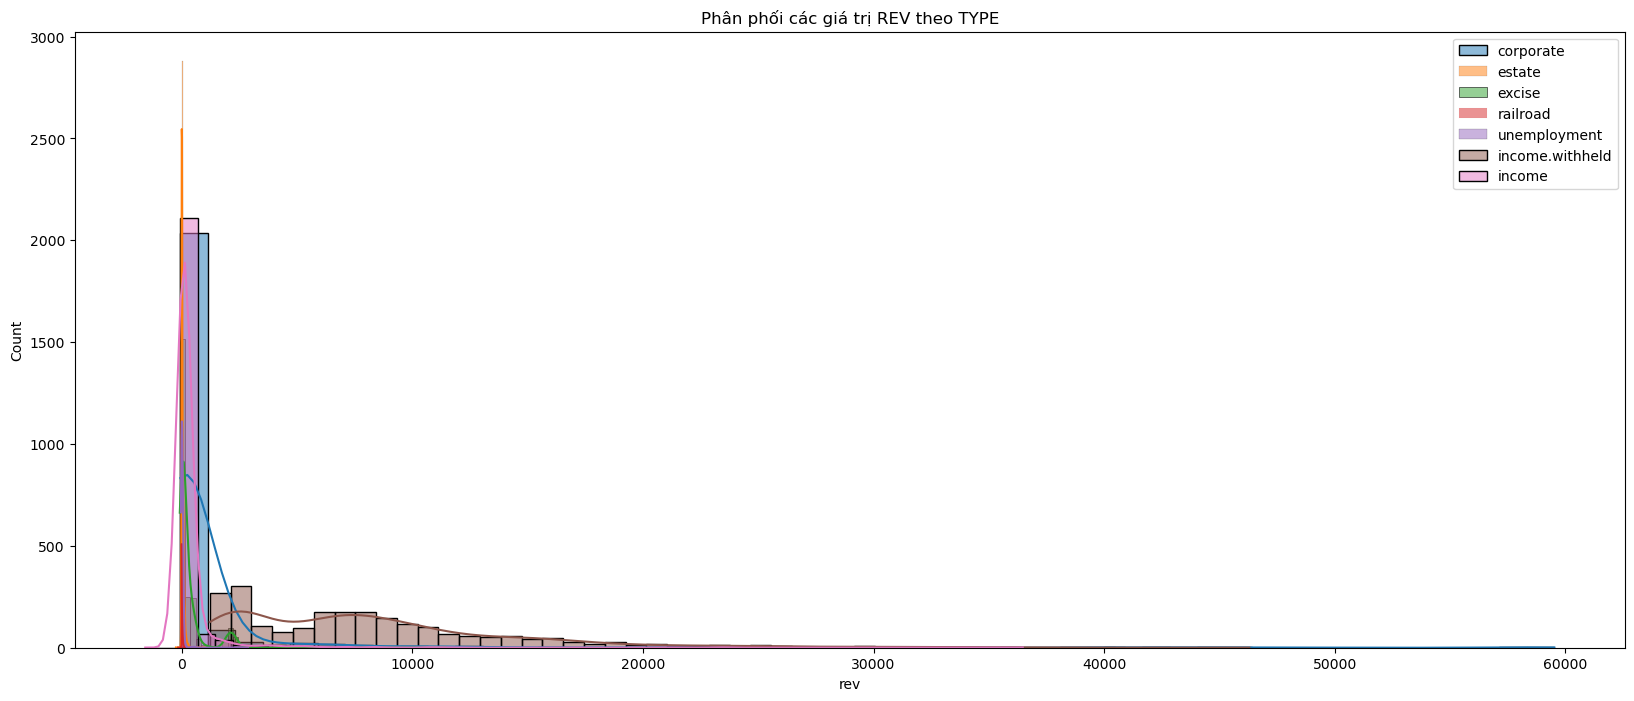

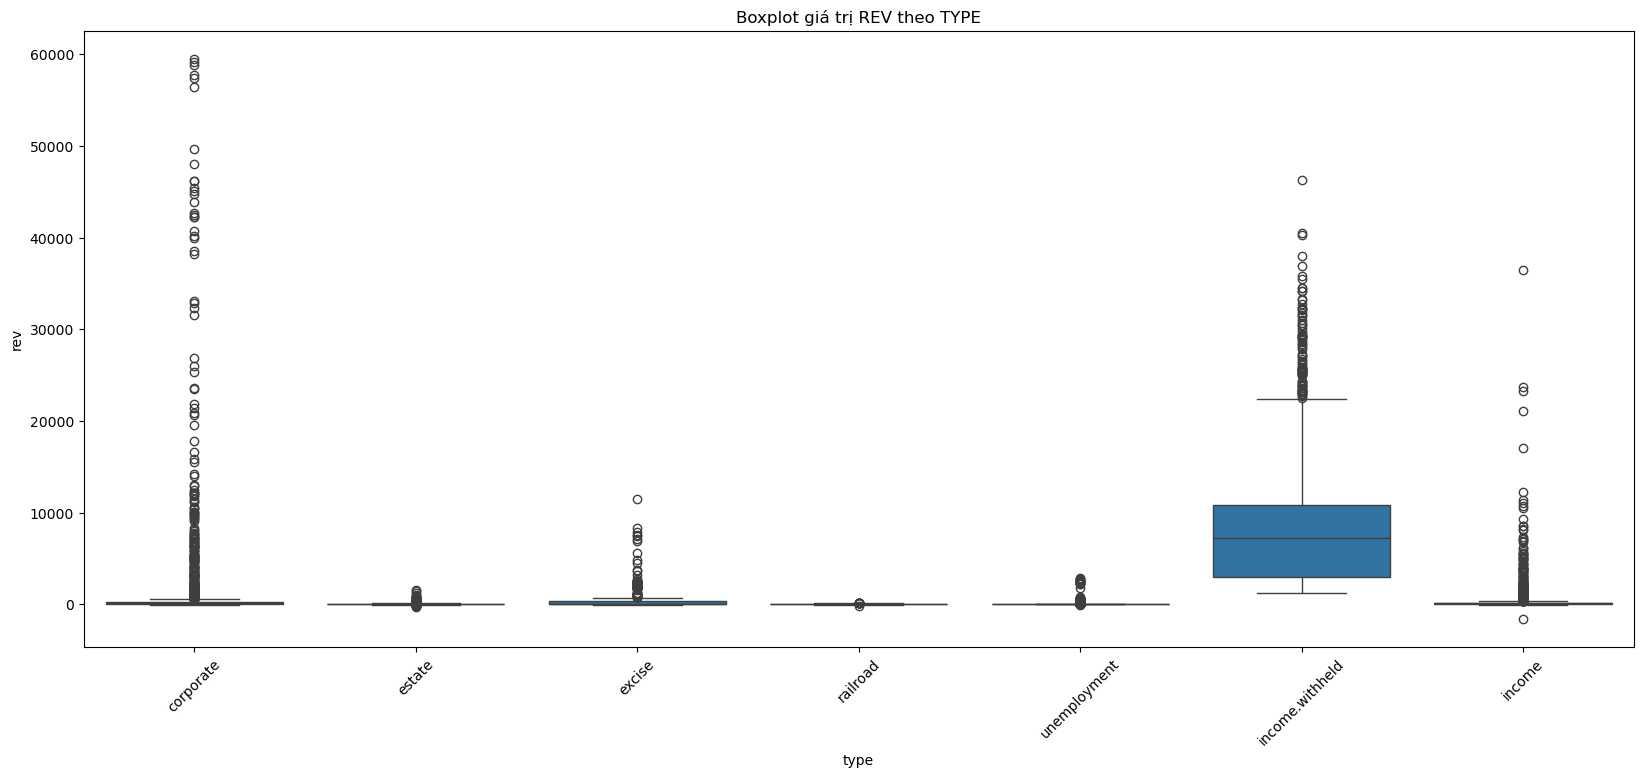

In [17]:
# Vẽ histogram theo type
plt.figure(figsize=(20, 8))
for t in df[type_col].unique():
    sns.histplot(df[df[type_col] == t][value_col], kde=True, label=t, bins=50)
plt.title('Phân phối các giá trị REV theo TYPE')
plt.legend()
plt.show()

# Vẽ boxplot theo type
plt.figure(figsize=(20, 8))
sns.boxplot(data=df, x=type_col, y=value_col)
plt.xticks(rotation=45)
plt.title('Boxplot giá trị REV theo TYPE')
plt.show()

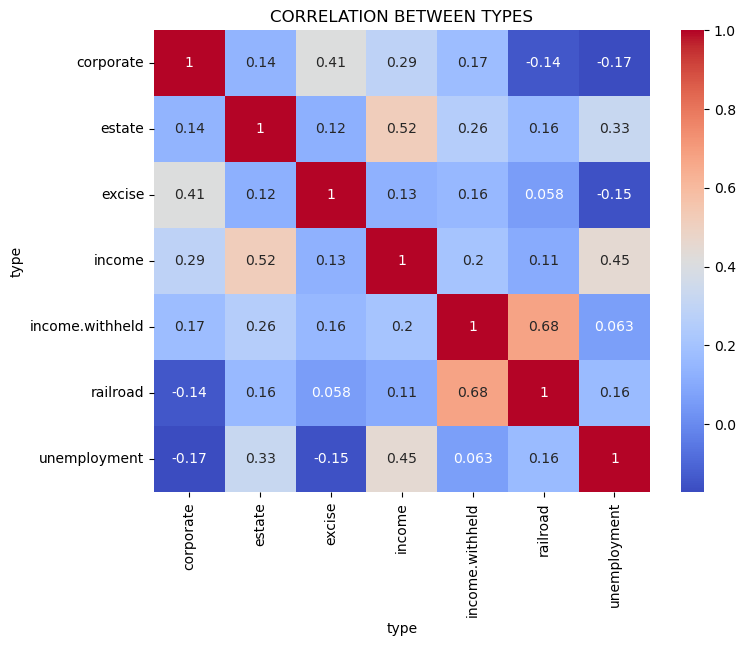

In [18]:
# pivot_table 
df_pivot = df.pivot_table(index=date_col, columns=type_col, values=value_col, aggfunc='sum')

# Resample và tính tổng theo tháng
df_pivot = df_pivot.resample('M').sum()

# heatmap correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_pivot.corr(), annot=True, cmap='coolwarm')
plt.title("CORRELATION BETWEEN TYPES")
plt.show()

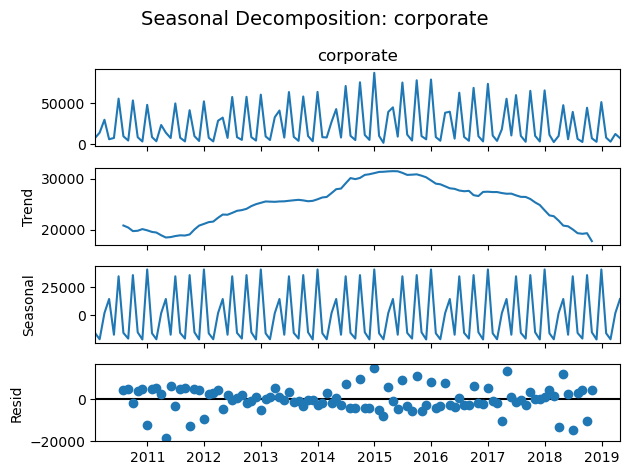

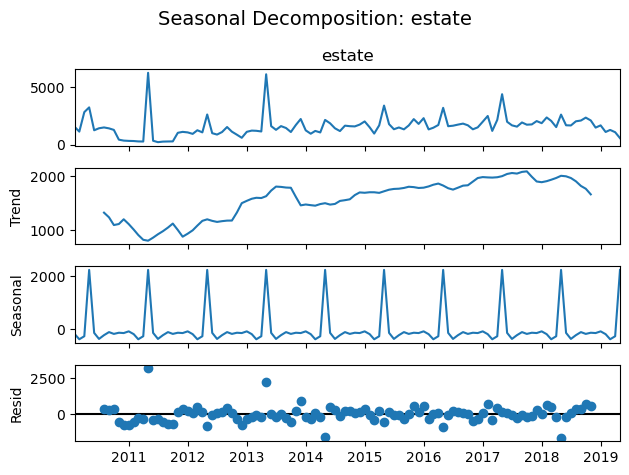

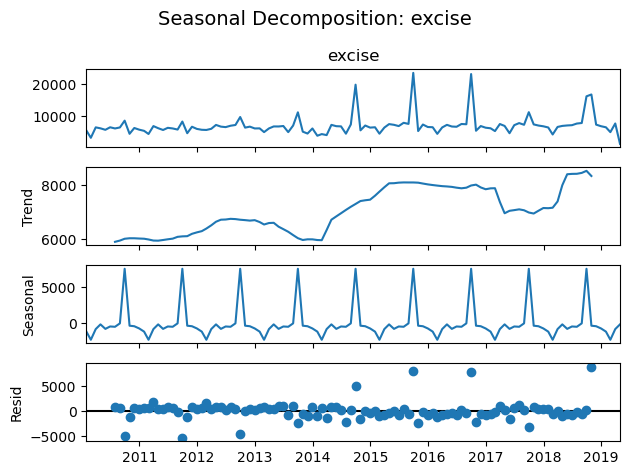

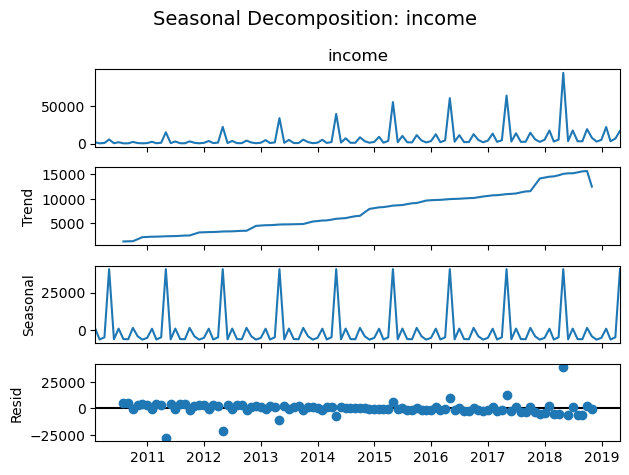

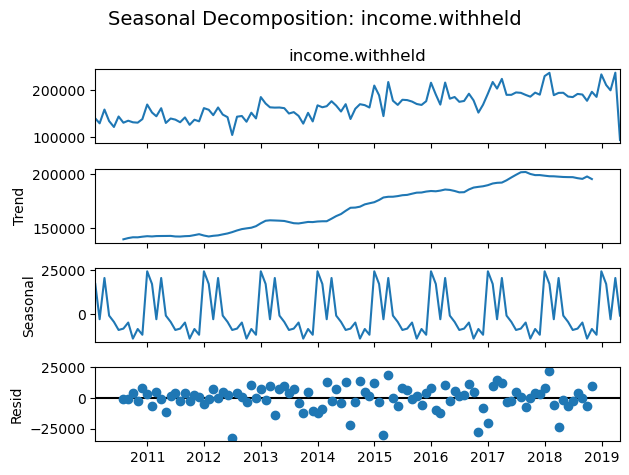

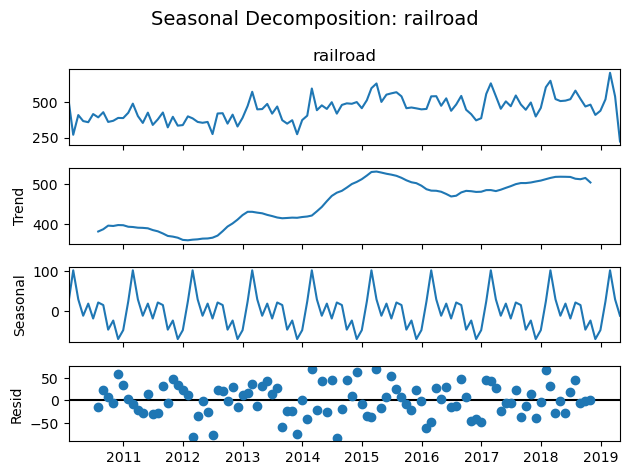

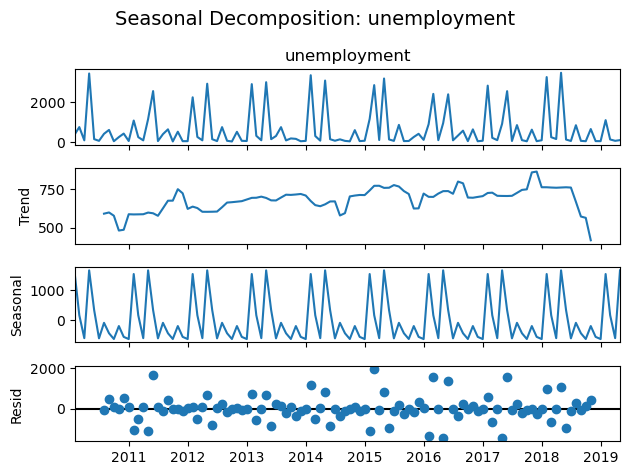

In [19]:
# Seasonal trend plot cho từng TYPE
import statsmodels.api as sm

for col in df_pivot.columns:
    try:
        decomposition = sm.tsa.seasonal_decompose(df_pivot[col].dropna(), model='additive', period=12)
        decomposition.plot()
        plt.suptitle(f'Seasonal Decomposition: {col}', fontsize=14)
        plt.tight_layout()
        plt.show()
    except:
        print(f"Không thể phân tích seasonal cho {col}")